# Rotación de un Púlsar

La fase de rotación se modela mediante una expansión de Taylor de la frecuencia:

$$\phi(t) = \phi_0 + 2\pi \left[ F_0 t' + \frac{1}{2}F_1 t'^2 + \frac{1}{6}F_2 t'^3 + \frac{1}{24}F_3 t'^4 \right]$$

donde $t' = t - \text{PEPOCH}$ es el tiempo relativo a la época de referencia, expresado en segundos.

Sus derivadas respecto al tiempo son:

$$\dot{\phi}(t) = 2\pi \left[ F_0 + F_1 t' + \frac{1}{2}F_2 t'^2 + \frac{1}{6}F_3 t'^3 \right]$$

$$\ddot{\phi}(t) = 2\pi \left[ F_1 + F_2 t' + \frac{1}{2}F_3 t'^2 \right]$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re

---
## 1. Lectura del archivo `.par`

Se lee y reestructura el archivo de parámetros y se extraen los valores numéricos.
Las líneas con coordenadas en formato sexagesimal (RAJ, DECJ) se omiten,
ya que no son relevantes para el modelo de rotación.

In [5]:
def leer_par(filename):
    """
    Lee un archivo .par y retorna un diccionario con los parámetros numéricos.
    """
    params = {}

    with open(filename, 'r') as f:
        for line in f:
            line = re.sub(r'\\', '', line).strip()  # Eliminar continuaciones de línea de TEMPO2

            if not line or line.startswith('#'):
                continue

            parts = line.split() #Divide las lineas ( [PEPOCH  60379] -> [PEPOCH,60379] )

            if len(parts) >= 2:
                #Crea el diccionario formato {key:val_str}
                key = parts[0]
                val_str = parts[1]

                try:
                    if ':' in val_str:  # Omitir RAJ, DECJ
                        continue
                    params[key] = float(val_str)
                except ValueError:
                    pass

    return params


params = leer_par('posg.par')

print('Parámetros leídos:')
for k, v in params.items():
    print(f'  {k:10s} = {v}')

Parámetros leídos:
  F0         = 61.88404726894926
  F1         = -1.9989467063920143e-10
  F2         = 7.810093326935054e-21
  F3         = 0.0
  PEPOCH     = 60379.0
  POSEPOCH   = 60379.0
  DMEPOCH    = 60379.0
  DM         = 0.0
  PMRA       = 0.0
  PMDEC      = 0.0
  PX         = 0.0
  START      = 60401.22127398062
  FINISH     = 60584.31296052359
  TZRMJD     = 60502.67873956879
  TZRFRQ     = 0.0
  TRES       = 126.032
  EPHVER     = 5.0
  NE_SW      = 4.0
  MODE       = 1.0
  NITS       = 1.0
  NTOA       = 6.0
  CHI2R      = 8.3104


---
## 2. Evaluación de $\dot{\phi}$ y $\ddot{\phi}$

Se evalúan ambas derivadas en 500 instantes de tiempo distribuidos a lo largo de 30 días a partir de PEPOCH. El tiempo se expresa en segundos para ser consistente con
las unidades de $F_0$ [Hz], $F_1$ [Hz/s], $F_2$ [Hz/s²] y $F_3$ [Hz/s³].

In [7]:
# Extraer parámetros; valor por defecto 0.0 si no están en el .par
F0     = params.get('F0',     0.0)
F1     = params.get('F1',     0.0)
F2     = params.get('F2',     0.0)
F3     = params.get('F3',     0.0)
PEPOCH = params.get('PEPOCH', 0.0)

# Intervalo temporal: 30 días desde PEPOCH, convertidos a segundos
t_mjd = np.linspace(PEPOCH, PEPOCH + 30, 500)
t = (t_mjd - PEPOCH) * 86400.0  # t' en segundos

# Primera derivada: frecuencia angular instantánea [rad/s]
phi_dot = 2*np.pi * (
    F0
    + F1 * t
    + 0.5 * F2 * t**2
    + (1/6) * F3 * t**3
)

# Segunda derivada: tasa de cambio de la frecuencia angular [rad/s²]
phi_ddot = 2*np.pi * (
    F1
    + F2 * t
    + 0.5 * F3 * t**2
)

print(f'phi_dot  inicial: {phi_dot[0]:.6f} rad/s')
print(f'phi_dot  final:   {phi_dot[-1]:.6f} rad/s')
print(f'phi_ddot inicial: {phi_ddot[0]:.6e} rad/s²')
print(f'phi_ddot final:   {phi_ddot[-1]:.6e} rad/s²')

phi_dot  inicial: 388.828937 rad/s
phi_dot  final:   388.825681 rad/s
phi_ddot inicial: -1.255975e-09 rad/s²
phi_ddot final:   -1.255848e-09 rad/s²


---
## 3. Gráficos

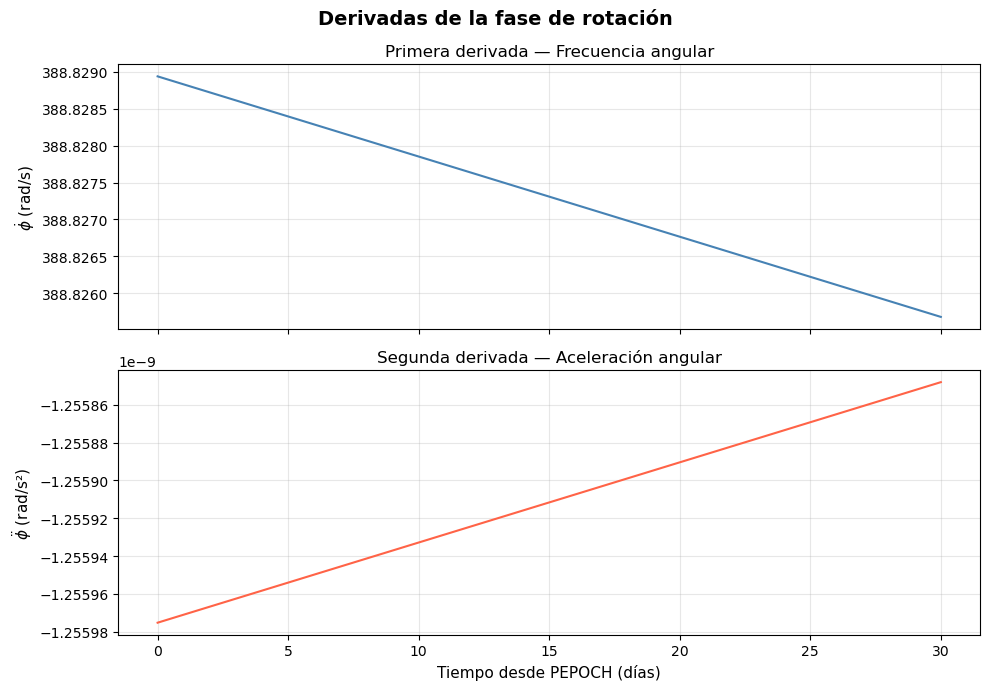

In [12]:
t_dias = t / 86400.0  # Eje X en días para mejor legibilidad

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Derivadas de la fase de rotación', fontsize=14, fontweight='bold')

# phi_dot: la pendiente negativa refleja el spin-down del púlsar
axs[0].plot(t_dias, phi_dot, color='steelblue', linewidth=1.5)
axs[0].set_ylabel('$\\dot{\\phi}$ (rad/s)', fontsize=11)
axs[0].set_title('Primera derivada — Frecuencia angular')
axs[0].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0].grid(True, alpha=0.3)

# phi_ddot: negativa y con leve tendencia creciente por la presencia de F2 (el pulsar se frena cada vez más lento, con una variacion minima)
axs[1].plot(t_dias, phi_ddot, color='tomato', linewidth=1.5)
axs[1].set_ylabel('$\\ddot{\\phi}$ (rad/s²)', fontsize=11)
axs[1].set_xlabel('Tiempo desde PEPOCH (días)', fontsize=11)
axs[1].set_title('Segunda derivada — Aceleración angular')
axs[1].ticklabel_format(useOffset=False, style='sci', scilimits=(0,0), axis='y') #Valores x10⁻⁹
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Lo que falta (personalmente)

El notebook está hecho para recibir solo un .par, debiese poder analizar varios a la vez. Con esto hecho, comparar propiedades de los pulsares.

Archivo .dat.

Más parametros fisicos: periodo, campo magnetico, densidad, tamaño, edad aparente, glitches, evolución.

Mejores graficos, y un analisis más profundo.



